# Activity Coefficient Models — Milestone 8.1

Cubic equations of state describe the **vapor** phase well but predict strongly non-ideal **liquid** mixtures (water + alcohol, say) poorly. The γ-φ approach fixes this by modelling the liquid with an *activity coefficient* $\gamma_i$ — a multiplier on Raoult's law that captures how much component $i$ 'dislikes' (γ > 1) or 'likes' (γ < 1) its neighbours. This milestone ports the five activity models of the research paper's Table 2.3, their excess properties $G^E, H^E, S^E$, and the saturated-liquid molar volumes that the Wilson and Scatchard-Hildebrand models depend on. Ref (4): Da Silva & Báez (1989); liquid volume: Hankinson & Thomson (18).

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context — the activity-coefficient method

From [Chapter II §2.2](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md), the liquid-phase fugacity in the γ-φ model is

$$\hat f_i^L = x_i\,\gamma_i\,f_i^0\,F_i,$$

where $F_i$ is the Poynting factor and $\gamma_i$ comes from one of the models in **Table 2.3**:

| Model | Parameters | $\ln\gamma_i$ |
|---|---|---|
| Wilson | $\Lambda_{ij}=(V_j^L/V_i^L)\,e^{-(\lambda_{ij}-\lambda_{ii})/RT}$ | $-\ln(\sum_j x_j\Lambda_{ij})+1-\sum_k x_k\Lambda_{ki}/\sum_j x_j\Lambda_{kj}$ |
| Scatchard-Hildebrand | $\delta_i,\;V_i^L$ | $V_i^L(\delta_i-\delta_{mix})^2/RT$, $\delta_{mix}=\sum_i\Phi_i\delta_i$ |
| Margules (binary) | $A_{12},A_{21}$ | $x_2^2[A_{12}+2(A_{21}-A_{12})x_1]$ |
| van Laar (binary) | $A_{12},A_{21}$ | $A_{12}/[1+(A_{12}x_1)/(A_{21}x_2)]^2$ |

and the **excess properties** follow directly from the activity coefficients (eqs 2.44–2.46):

$$G^E = RT\sum_i x_i\ln\gamma_i,\quad H^E = -T^2\,\partial(G^E/T)/\partial T,\quad S^E = (H^E-G^E)/T.$$

Per the project's algorithm rules the temperature derivative in $H^E$ is **analytical**. The Wilson, Scatchard, and van Laar models need a liquid molar volume $V_i^L$, obtained from the Rackett or Thomson/COSTALD (18) correlation.

## What was built in Milestone 8.1

Through `vle._engine`:

- `liquid_molar_volume(model, tc, pc, t, zra=…, vstar=…, omega_srk=…)` — Rackett (`VolumeModel.Rackett`) or Thomson/COSTALD (`VolumeModel.Thomson`), returning cm³/mol.
- `activity_ln_gamma(model, i, x, aij, vl=…, delta=…, t=…)` — $\ln\gamma_i$ for any of the five `ActivityModel` variants.
- `activity_excess_gibbs / _enthalpy / _entropy(model, x, aij, …)` — $G^E, H^E, S^E$ in kJ/kmol (and kJ/(kmol·K) for $S^E$).

The `aij` matrix convention is per-model: Wilson uses interaction energies $\lambda_{ij}-\lambda_{ii}$ in kJ/kmol; van Laar/Margules use dimensionless $A_{ij}$ with zero diagonal; Scatchard/Ideal ignore it.

## Worked example — ethanol (1) / water (2)

A textbook positively-deviating binary. We first get the liquid molar volumes from Rackett, then drive the activity models with them.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vle._engine as e
%matplotlib inline

print('vle-thermo', e.version())

T = 298.15  # K
# Critical data + Rackett ZRA for ethanol and water.
ETHANOL = dict(tc=513.9, pc=6148.0, zra=0.248)
WATER   = dict(tc=647.3, pc=22120.0, zra=0.235)

vl = [
    e.liquid_molar_volume(e.VolumeModel.Rackett, ETHANOL['tc'], ETHANOL['pc'], T, zra=ETHANOL['zra']),
    e.liquid_molar_volume(e.VolumeModel.Rackett, WATER['tc'],   WATER['pc'],   T, zra=WATER['zra']),
]
print(f'V_L  ethanol={vl[0]:.1f}  water={vl[1]:.1f}  cm3/mol')
assert 50 < vl[0] < 65 and 15 < vl[1] < 20

vle-thermo 0.6.0
V_L  ethanol=58.1  water=17.0  cm3/mol


### Activity coefficients vs composition

We use a van Laar fit ($A_{12}=1.6$, $A_{21}=0.9$) and a Wilson fit (energies in kJ/kmol). Both should give $\gamma_i \to 1$ as $x_i \to 1$ (pure component) and the largest $\gamma_i$ at infinite dilution.

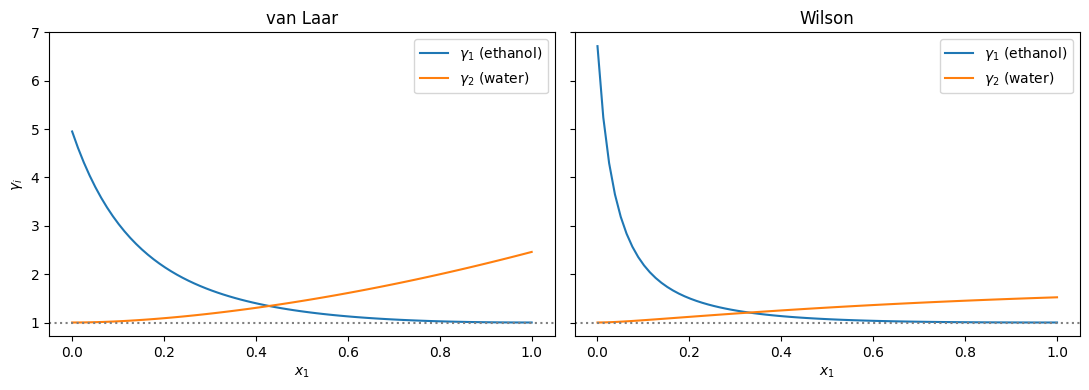

In [3]:
x1 = np.linspace(1e-4, 1 - 1e-4, 80)

vanlaar_aij = [[0.0, 1.6], [0.9, 0.0]]          # dimensionless A12, A21
wilson_aij  = [[0.0, 3300.0], [1800.0, 0.0]]    # (lambda_ij - lambda_ii) kJ/kmol

def gammas(model, aij, **kw):
    g1, g2 = [], []
    for a in x1:
        xs = [a, 1 - a]
        g1.append(np.exp(e.activity_ln_gamma(model, 0, xs, aij, t=T, **kw)))
        g2.append(np.exp(e.activity_ln_gamma(model, 1, xs, aij, t=T, **kw)))
    return np.array(g1), np.array(g2)

vl_g1, vl_g2 = gammas(e.ActivityModel.VanLaar, vanlaar_aij)
wi_g1, wi_g2 = gammas(e.ActivityModel.Wilson, wilson_aij, vl=vl)

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax[0].plot(x1, vl_g1, label=r'$\gamma_1$ (ethanol)')
ax[0].plot(x1, vl_g2, label=r'$\gamma_2$ (water)')
ax[0].set_title('van Laar'); ax[0].set_xlabel(r'$x_1$'); ax[0].set_ylabel(r'$\gamma_i$'); ax[0].legend()
ax[1].plot(x1, wi_g1, label=r'$\gamma_1$ (ethanol)')
ax[1].plot(x1, wi_g2, label=r'$\gamma_2$ (water)')
ax[1].set_title('Wilson'); ax[1].set_xlabel(r'$x_1$'); ax[1].legend()
for a in ax: a.axhline(1.0, ls=':', c='grey')
plt.tight_layout(); plt.show()

# Pure-component limits: gamma -> 1.
assert abs(vl_g1[-1] - 1.0) < 1e-2 and abs(vl_g2[0] - 1.0) < 1e-2
# van Laar infinite-dilution limit: ln gamma_1 -> A12.
assert abs(np.log(vl_g1[0]) - 1.6) < 1e-2

### Excess Gibbs energy and enthalpy

$G^E$ vanishes at both pure limits and peaks near equimolar. For Wilson the temperature dependence of $\Lambda_{ij}$ makes $H^E \ne G^E$ (a real heat of mixing); for van Laar the legacy convention gives $H^E = G^E$.

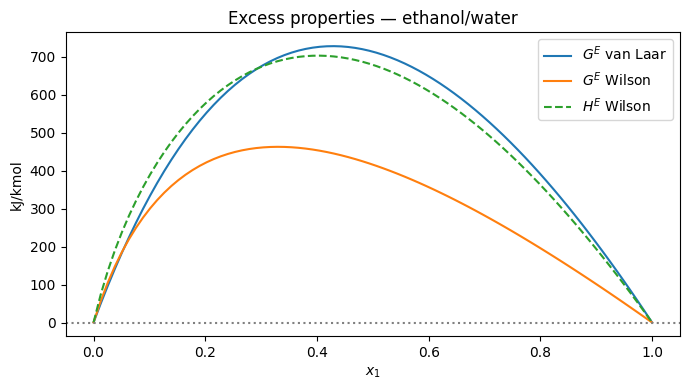

In [4]:
ge_vl = [e.activity_excess_gibbs(e.ActivityModel.VanLaar, [a, 1 - a], vanlaar_aij, t=T) for a in x1]
ge_wi = [e.activity_excess_gibbs(e.ActivityModel.Wilson, [a, 1 - a], wilson_aij, vl=vl, t=T) for a in x1]
he_wi = [e.activity_excess_enthalpy(e.ActivityModel.Wilson, [a, 1 - a], wilson_aij, vl=vl, t=T) for a in x1]

plt.figure(figsize=(7, 4))
plt.plot(x1, ge_vl, label=r'$G^E$ van Laar')
plt.plot(x1, ge_wi, label=r'$G^E$ Wilson')
plt.plot(x1, he_wi, '--', label=r'$H^E$ Wilson')
plt.axhline(0.0, ls=':', c='grey')
plt.xlabel(r'$x_1$'); plt.ylabel('kJ/kmol')
plt.title('Excess properties — ethanol/water'); plt.legend(); plt.tight_layout(); plt.show()

# G^E vanishes at the pure limits.
assert abs(ge_wi[0]) < 1.0 and abs(ge_wi[-1]) < 1.0

### The analytical $H^E$ is exact

The engine's analytical Wilson $H^E$ matches a finite-difference evaluation of $-T^2\,d(G^E/T)/dT$ — the test-oracle pattern the project uses everywhere derivatives appear.

In [5]:
xs = [0.4, 0.6]
h = 1e-2
g_over_t = lambda tt: e.activity_excess_gibbs(e.ActivityModel.Wilson, xs, wilson_aij, vl=vl, t=tt) / tt
he_num = -T * T * (g_over_t(T + h) - g_over_t(T - h)) / (2 * h)
he_ana = e.activity_excess_enthalpy(e.ActivityModel.Wilson, xs, wilson_aij, vl=vl, t=T)
print(f'H^E analytical = {he_ana:8.2f} kJ/kmol   numerical = {he_num:8.2f} kJ/kmol')
assert abs(he_ana - he_num) < 1e-2 * abs(he_num)

H^E analytical =   703.47 kJ/kmol   numerical =   703.47 kJ/kmol


## Exercise 1 — Margules vs van Laar

Using the same $A_{12}=1.6$, $A_{21}=0.9$, plot $\ln\gamma_1$ vs $x_1$ for **both** the Margules and van Laar models on one axis. Where do they differ most? Fill in the `# TODO`.

In [6]:
aij = [[0.0, 1.6], [0.9, 0.0]]
# TODO: build lists `lg_marg` and `lg_vl` of ln(gamma_1) over x1 for the
# Margules and van Laar models, then plot both against x1.


<details><summary>Solution</summary>

```python
lg_marg = [e.activity_ln_gamma(e.ActivityModel.Margules, 0, [a, 1 - a], aij) for a in x1]
lg_vl   = [e.activity_ln_gamma(e.ActivityModel.VanLaar,  0, [a, 1 - a], aij) for a in x1]
plt.figure(figsize=(7, 4))
plt.plot(x1, lg_marg, label='Margules')
plt.plot(x1, lg_vl, label='van Laar')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$\ln\gamma_1$')
plt.title('Margules vs van Laar'); plt.legend(); plt.tight_layout(); plt.show()
# They agree at the dilute and pure limits; the largest gap is mid-range.
```
</details>

## Exercise 2 — Scatchard-Hildebrand needs no fitting

The Scatchard-Hildebrand (regular-solution) model is *predictive*: it needs only pure-component solubility parameters $\delta_i$ and liquid volumes — no binary data. For a non-polar pair ($\delta_1 = 7.4$, $\delta_2 = 8.9\,(\mathrm{cal/cm^3})^{0.5}$, $V^L = [131, 89]\,\mathrm{cm^3/mol}$), compute and plot $\gamma_1$ across composition, then confirm $\gamma_1 \to 1$ as $x_1 \to 1$.

In [7]:
delta = [7.4, 8.9]
vl_sh = [131.0, 89.0]
# TODO: g1 = exp(activity_ln_gamma(ScatchardHildebrand, 0, [a,1-a], [[0,0],[0,0]],
#       vl=vl_sh, delta=delta, t=T)) for a in x1; plot; assert the pure limit.


<details><summary>Solution</summary>

```python
g1 = [np.exp(e.activity_ln_gamma(e.ActivityModel.ScatchardHildebrand, 0, [a, 1 - a],
      [[0.0, 0.0], [0.0, 0.0]], vl=vl_sh, delta=delta, t=T)) for a in x1]
plt.figure(figsize=(7, 4))
plt.plot(x1, g1)
plt.axhline(1.0, ls=':', c='grey')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$\gamma_1$')
plt.title('Scatchard-Hildebrand (predictive)'); plt.tight_layout(); plt.show()
assert abs(g1[-1] - 1.0) < 1e-2
```
</details>

## References

- **(4)** Da Silva, F. A.; Báez, L. (1989) — the five activity models and excess properties (`legacy/pascal/TERMOIII.PAS`, `legacy/vb6/clsActivityMulticomp.cls`).
- **(18)** Hankinson, R. W.; Thomson, G. H. — COSTALD liquid molar volume.
- [Chapter II §2.2](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md) — activity-coefficient method and Table 2.3.
- [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/docs/plans/MODERNIZATION_PLAN.md) — Phase 10 (activity models).
- Previous notebook: [`02d_advanced_saturation.ipynb`](02d_advanced_saturation.ipynb).